<a href="https://colab.research.google.com/github/ada-eg225/Data-Science/blob/main/Second_%20commit_Assessment_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some initial imports, do **NOT** write any new code here:

In [1]:
import os
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import time

import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from huggingface_hub import hf_hub_download





# Question 1: MRI Modality Translation (T1 → T2)

Magnetic Resonance Imaging (MRI) is a key modality for brain and brain tumour assessment. Different MRI contrasts highlight different tissue properties: for example, T1-weighted images provide good anatomical detail, while T2-weighted images are more sensitive to fluid and oedema, and often make tumour-related abnormalities more conspicuous. In clinical practice, not all contrasts are always acquired for every patient or every time point, and multi-contrast data can be incomplete or heterogeneous. Learning mappings between MRI modalities is therefore relevant for tasks such as image completion, protocol harmonisation, and data augmentation.

In this question you will work with a pre-processed dataset derived from a public brain tumour MRI collection. For each patient, paired **T1** and **T2** images have been extracted as **2D slices** from 3D volumes in several canonical views (axial, sagittal, coronal). The data have been co-registered, skull-stripped, and resampled to **single-channel 64×64** slices and split into **training** and **validation** sets. Each example includes:
- `patient_id`: an anonymised identifier for the patient  
- `split`: the dataset split (`train` or `validation`)  
- `view`: the anatomical view (`axial`, `sagittal`, or `coronal`)  
- `t1`: a 2D T1-weighted slice (shape `(1, 64, 64)`)  
- `t2`: the corresponding T2-weighted slice (same shape as `t1`)

Throughout this question, you will treat **T1 slices as inputs** and **T2 slices as targets** in an image-to-image regression setting.

This question is divided into three parts:

- **Part 1.A – Exploratory Data Analysis and Pre-processing**: you will inspect the dataset, develop simple visualisations, and design a basic intensity normalisation pipeline.  
- **Part 1.B – Modality Translation Model**: you will build and train a deep learning model that maps T1 slices to T2 slices, and evaluate its performance quantitatively and qualitatively.  
- **Part 1.C – Discussion**: you will critically reflect on your modelling choices, results, and limitations in a concise written analysis.

<br>

---

<br>

The next few blocks of code provided in the notebook will download and load the dataset from the Hugging Face Hub, and show you basic usage of the `datasets` API for accessing slices and metadata.


In [2]:
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  ##uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. -
    torch.backends.cudnn.enabled   = False

    return True

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")

Cuda installed! Running on GPU!


In [3]:
train_dataset = load_dataset("dpelacani/mri-t1-t2-2D-sliced-64", split="train")
valid_dataset = load_dataset("dpelacani/mri-t1-t2-2D-sliced-64", split="validation")

train_dataset, valid_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/711 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/232M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/223M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

...

data/validation-00000-of-00002.parquet:   0%|          | 0.00/175M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/183M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/116235 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/39375 [00:00<?, ? examples/s]

(Dataset({
     features: ['patient_id', 'split', 'view', 't1', 't2'],
     num_rows: 116235
 }),
 Dataset({
     features: ['patient_id', 'split', 'view', 't1', 't2'],
     num_rows: 39375
 }))

In [4]:
# Applying a transform to the dataset, this can also incluse torchvision transforms
def basic_transform_fn(sample_):
    if "t1" in sample_:
        sample_["t1"] = torch.tensor(sample_["t1"])
    if "t2" in sample_:
        sample_["t2"] = torch.tensor(sample_["t2"])
    return sample_

train_dataset = train_dataset.with_transform(basic_transform_fn)
valid_dataset = valid_dataset.with_transform(basic_transform_fn)

train_dataset[0]["t1"].shape, valid_dataset[0]["t1"].shape


(torch.Size([1, 64, 64]), torch.Size([1, 64, 64]))

<br><br>

## 1.A) Exploratory Data Analysis and Pre-processing

In this part you will carry out basic exploratory analysis of the paired T1/T2 slice dataset and design a simple pre-processing strategy that will be reused in Part 1.B.

Using the provided loading code and any helper functions you choose to implement, you should:

1. **Visualise representative T1–T2 pairs**  
   - For each anatomical view, plot a small grid of 8 T1/T2 pairs from the training set. Arrange the plots so that for each example the T1 input and its corresponding T2 target can be compared side-by-side (or in successive rows), and ensure that axes and titles are clearly labelled.

2. **Analyse intensity distributions**  
   - Plot histograms (or density plots) of pixel intensities for T1 and T2 slices, separately for the training and validation sets.  

3. **Design a simple intensity pre-processing transform**  
   - Based on your histograms of (2), propose and implement a basic normalisation scheme for `t1` and `t2` that is suitable for the task you will be carrying out in Part 1.B. For instance, you might try scaling the pixels to a fixed range such as \([0,1]\) or \([-1,1]\)) if you feel that is appropriate.

   - Apply this transform to the dataset and re-plot a few T1/T2 pairs and intensity histograms to verify that the transformed images are numerically well-behaved while preserving relevant anatomical structure.  


<br>

---

<br>

Write your answer to this question below. You can use as many code and text blocks as needed.

Please, **make sure to thoroughly describe and comment every piece of code that you include in your answer**. You will be expected to understand every line of code that you write.

<br>

1. **Visualise representative T1–T2 pairs**

Views in dataset: ['axial', 'sagittal', 'coronal']


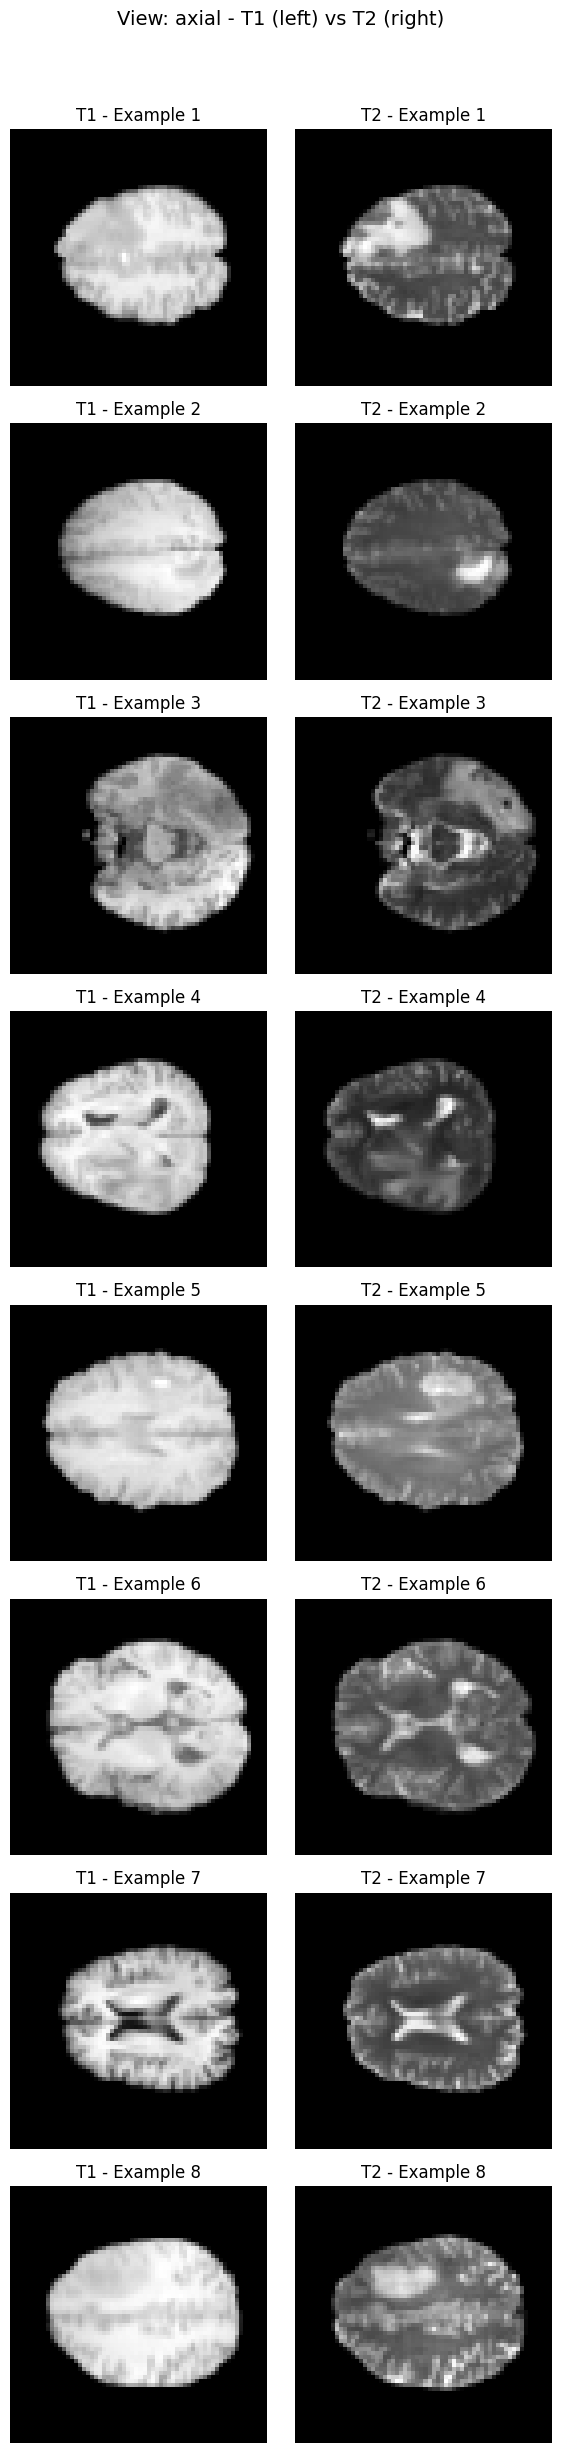

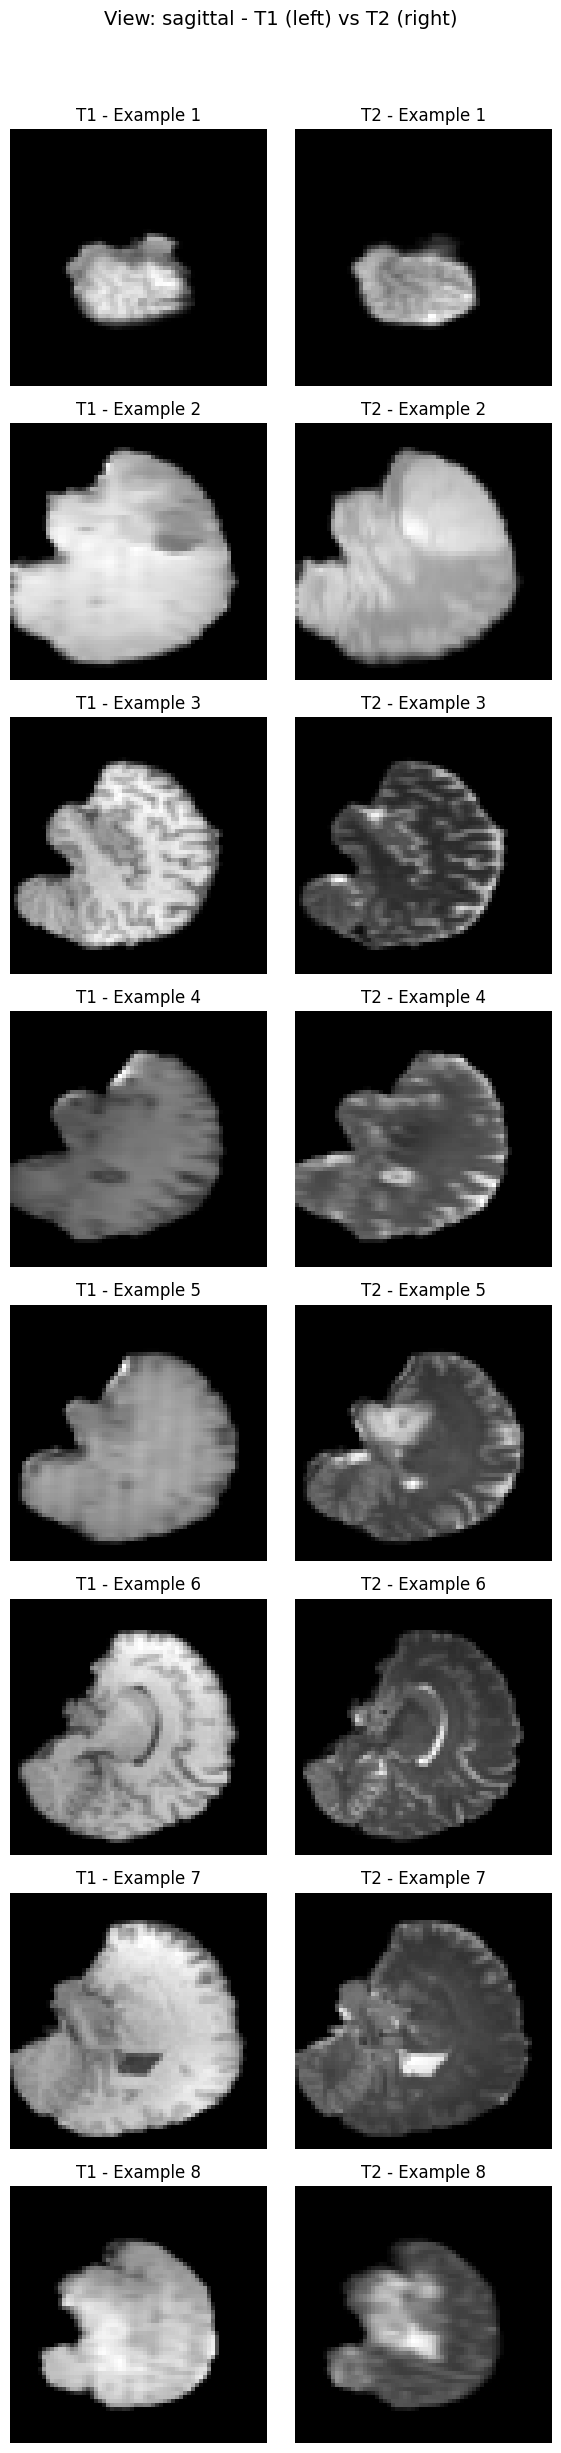

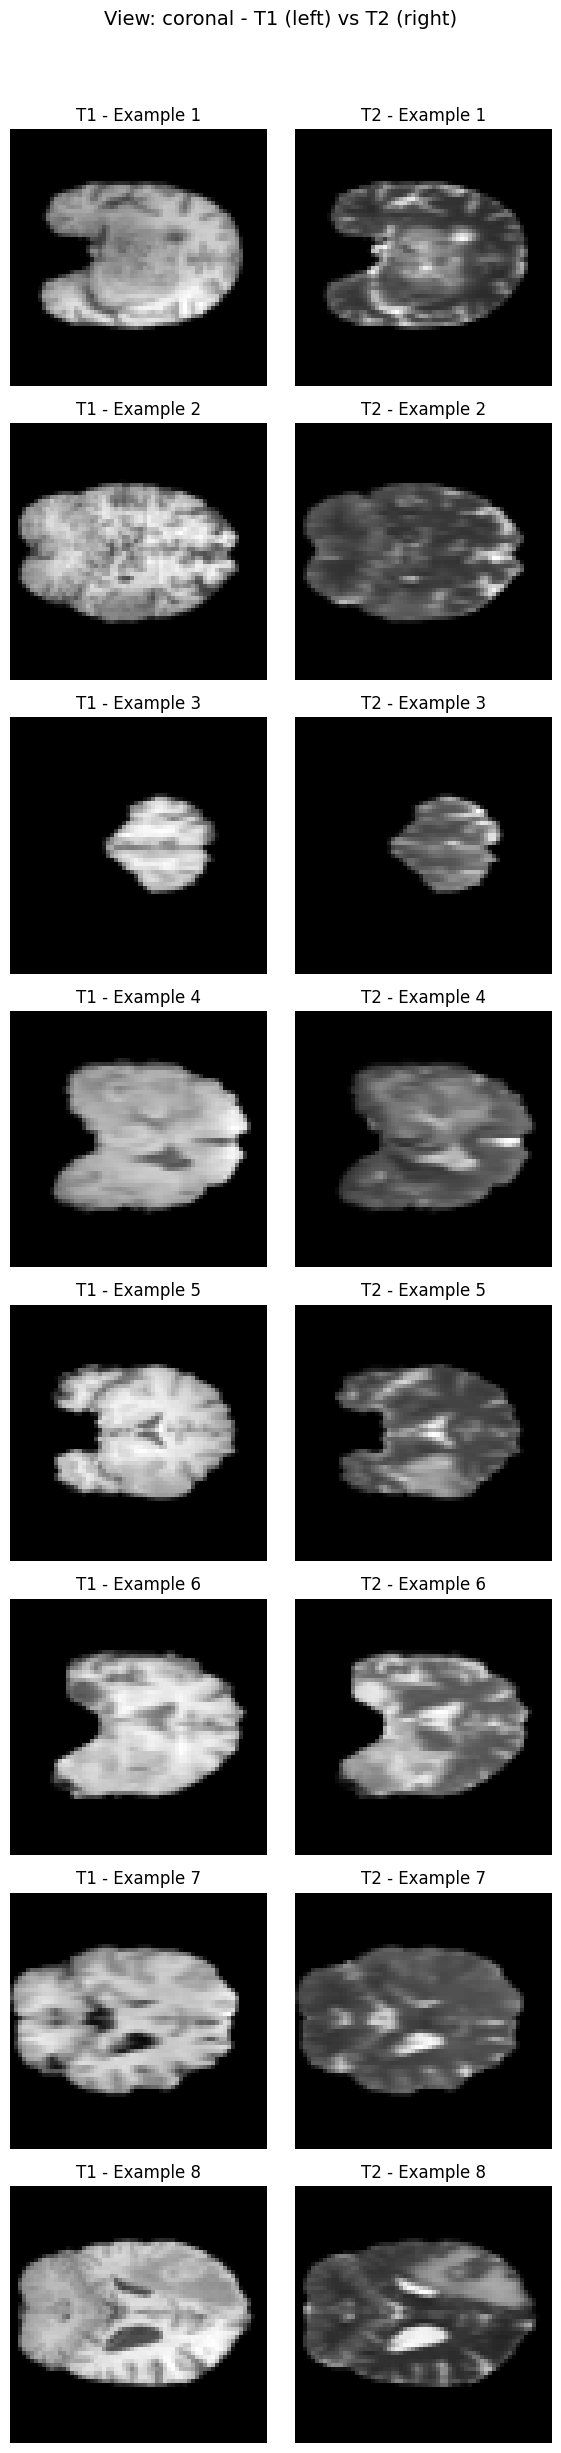

In [ ]:
# Splitting for the unique values inside view : axial, sagittal and coronal.
views = train_dataset.unique('view')
print("Views in dataset:", views)

# Setup: for each view I will show 8 examples with it's corresponding T1 and T2
# for clarity it will be displayed in rows in order to compare the pairs.

for view in views:
    # Filter dataset for this view
    view_samples = train_dataset.filter(lambda x: x['view'] == view)

    # Randomly pick 8 indices
    indices = np.random.choice(len(view_samples), size=8, replace=False)

    # Create grid for plotting
    fig, axes = plt.subplots(8, 2, figsize=(6, 24))
    fig.suptitle(f'View: {view} - T1 (left) vs T2 (right)', fontsize=14, y=1.02)

    for i, idx in enumerate(indices):
        sample = view_samples[int(idx)]
        t1 = sample['t1'].squeeze().numpy()  # shape (64, 64)
        t2 = sample['t2'].squeeze().numpy()

        # T1
        axes[i, 0].imshow(t1, cmap='gray')
        axes[i, 0].set_title(f"T1 - Example {i+1}")
        axes[i, 0].axis('off')

        # T2
        axes[i, 1].imshow(t2, cmap='gray')
        axes[i, 1].set_title(f"T2 - Example {i+1}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

<br>

2. **Analyse intensity distributions**  

In [ ]:
def sample_pixel_intensities(dataset, n_images=1000, n_pixels_per_image=100):
    """
    This function shows the intensity of the values per pixel from a random
    sample of both datasets.
    """
    # Creation of the arrays
    t1_pixels = []
    t2_pixels = []

    # Sample selection according to the lenght of the dataset and the input val
    # defined in the function
    total_images = len(dataset)
    indices = np.random.choice(total_images, size=min(n_images, total_images), replace=False)

    for idx in tqdm(indices, desc="Sampling pixels"):
        sample = dataset[int(idx)]
        t1 = sample['t1'].numpy().squeeze()  # Convert to numpy (64, 64)
        t2 = sample['t2'].numpy().squeeze()

        # Collapse samples into 1 dimension
        flat_t1 = t1.flatten()
        flat_t2 = t2.flatten()
        # For memory optimization we only select some pixel from the sample
        # image, so we improve handling them in further lines
        if len(flat_t1) > n_pixels_per_image:
            pixel_idx = np.random.choice(len(flat_t1), n_pixels_per_image, replace=False)
            t1_pixels.extend(flat_t1[pixel_idx])
            t2_pixels.extend(flat_t2[pixel_idx])
        else:
            t1_pixels.extend(flat_t1)
            t2_pixels.extend(flat_t2)

    return np.array(t1_pixels), np.array(t2_pixels)

# Call function for train and validation with the sample size needed and the
# number of pixels per image.
print("Sampling from training set...")
train_t1_samples, train_t2_samples = sample_pixel_intensities(train_dataset, n_images=500, n_pixels_per_image=200)

print("\nSampling from validation set...")
val_t1_samples, val_t2_samples = sample_pixel_intensities(valid_dataset, n_images=500, n_pixels_per_image=200)

print(f"Train samples: {len(train_t1_samples):,} T1 pixels, {len(train_t2_samples):,} T2 pixels")
print(f"Val samples: {len(val_t1_samples):,} T1 pixels, {len(val_t2_samples):,} T2 pixels")

Sampling from training set...


Sampling pixels: 100%|██████████| 500/500 [00:02<00:00, 177.83it/s]



Sampling from validation set...


Sampling pixels: 100%|██████████| 500/500 [00:03<00:00, 126.67it/s]

Train samples: 100,000 T1 pixels, 100,000 T2 pixels
Val samples: 100,000 T1 pixels, 100,000 T2 pixels


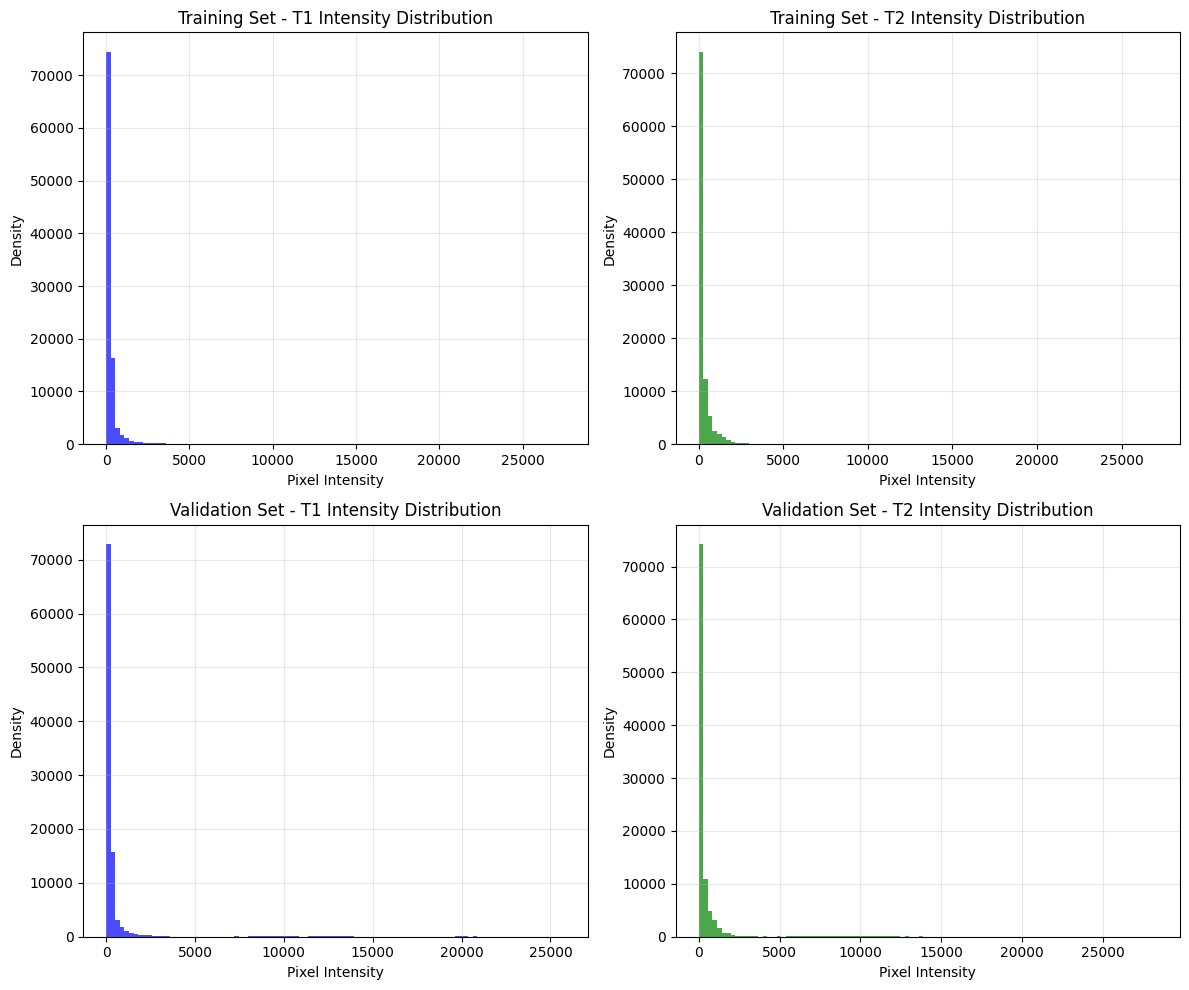

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Histograms for validation and training datasets
# Training set
axes[0, 0].hist(train_t1_samples, bins=100, alpha=0.7, color='blue')
axes[0, 0].set_title('Training Set - T1 Intensity Distribution')
axes[0, 0].set_xlabel('Pixel Intensity')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(train_t2_samples, bins=100, alpha=0.7, color='green')
axes[0, 1].set_title('Training Set - T2 Intensity Distribution')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# Validation set
axes[1, 0].hist(val_t1_samples, bins=100, alpha=0.7, color='blue')
axes[1, 0].set_title('Validation Set - T1 Intensity Distribution')
axes[1, 0].set_xlabel('Pixel Intensity')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(val_t2_samples, bins=100, alpha=0.7, color='green')
axes[1, 1].set_title('Validation Set - T2 Intensity Distribution')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def print_stats(name, t1_samples, t2_samples):
    'This function plot the statistics of the training and the validation dataset'
    print(f"\n{name}:")
    print(f"  T1 - Min: {t1_samples.min():.2f}, Max: {t1_samples.max():.2f}, "
          f"Mean: {t1_samples.mean():.2f}, Std: {t1_samples.std():.2f}")
    print(f"  T2 - Min: {t2_samples.min():.2f}, Max: {t2_samples.max():.2f}, "
          f"Mean: {t2_samples.mean():.2f}, Std: {t2_samples.std():.2f}")

print_stats("Training Set", train_t1_samples, train_t2_samples)
print_stats("Validation Set", val_t1_samples, val_t2_samples)




Training Set:
  T1 - Min: 0.00, Max: 27525.85, Mean: 245.01, Std: 796.65
  T2 - Min: 0.00, Max: 27092.17, Mean: 275.73, Std: 955.25

Validation Set:
  T1 - Min: 0.00, Max: 25794.00, Mean: 563.47, Std: 2434.98
  T2 - Min: 0.00, Max: 28322.50, Mean: 477.31, Std: 1805.58


<br>

3. **Design a simple intensity pre-processing transform**

In [5]:
class RobustNormalize:
    """
    Robust normalization and Z score for each image with a soft clip for
    big outliers.
    """
    def __init__(self, clip_sigma=4.0):  # sigma clip  4 after Z score normalization
        self.clip_sigma = clip_sigma

    def __call__(self, sample):
        t1 = sample['t1'].float()
        t2 = sample['t2'].float()

        # Mean and std per image
        t1_mean, t1_std = t1.mean(), t1.std()
        t2_mean, t2_std = t2.mean(), t2.std()

        # Avoid 0 division in Z score
        t1_std = max(t1_std, 1e-8)
        t2_std = max(t2_std, 1e-8)

        # Z-score calculation
        t1_norm = (t1 - t1_mean) / t1_std
        t2_norm = (t2 - t2_mean) / t2_std

        # Soft clip for outliers +- 4 times std
        if self.clip_sigma:
            t1_norm = torch.clamp(t1_norm, -self.clip_sigma, self.clip_sigma)
            t2_norm = torch.clamp(t2_norm, -self.clip_sigma, self.clip_sigma)

        # Scaling between 0 - 1
        t1_norm = (t1_norm + self.clip_sigma) / (2 * self.clip_sigma)
        t2_norm = (t2_norm + self.clip_sigma) / (2 * self.clip_sigma)

        return {'t1': t1_norm, 't2': t2_norm, 'view': sample['view'], 'patient_id': sample['patient_id']}

In [6]:
# Applying normalization
robust_normalizer = RobustNormalize(clip_sigma=4.0)

# Transformaton function for on the fly application
def robust_transform(sample):
    # Ensure every sample input is a tensor
    if not torch.is_tensor(sample['t1']):
        sample['t1'] = torch.tensor(sample['t1'])
    if not torch.is_tensor(sample['t2']):
        sample['t2'] = torch.tensor(sample['t2'])

    return robust_normalizer(sample)

# create datasets with normalization
train_dataset_robust = train_dataset.with_transform(robust_transform)
valid_dataset_robust = valid_dataset.with_transform(robust_transform)

=== TRAINING SET ===


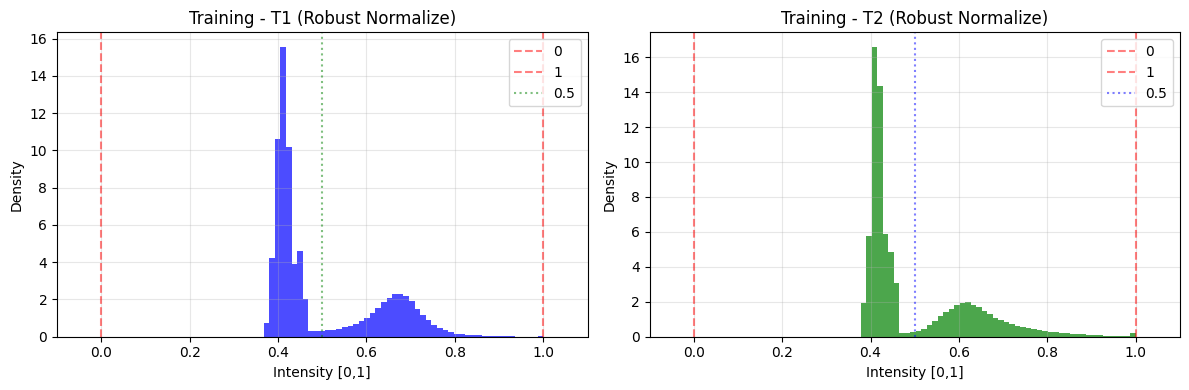

Training:
  T1 - Min: 0.367, Max: 1.000, Mean: 0.500, Std: 0.125
  T2 - Min: 0.378, Max: 1.000, Mean: 0.500, Std: 0.124

=== VALIDATION SET ===


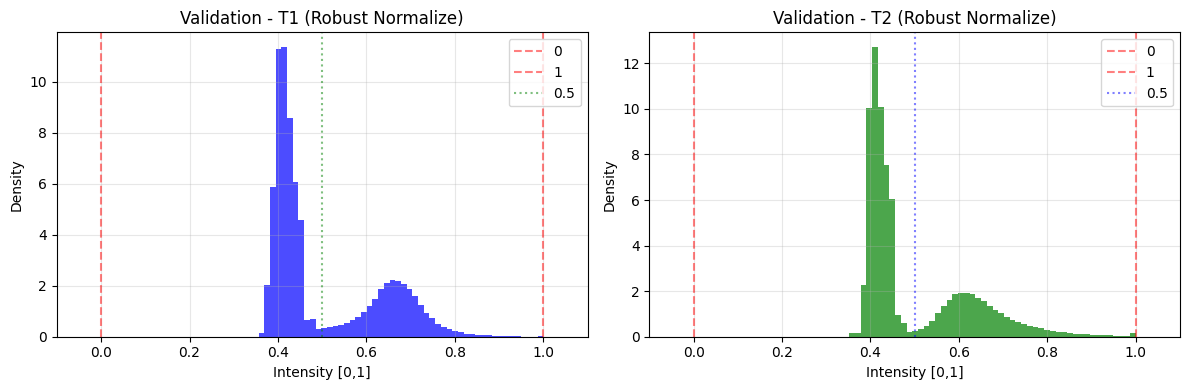

Validation:
  T1 - Min: 0.356, Max: 1.000, Mean: 0.500, Std: 0.125
  T2 - Min: 0.352, Max: 1.000, Mean: 0.500, Std: 0.124


In [ ]:
def plot_robust_histograms(dataset, title, n_samples=200):
    t1_vals, t2_vals = [], []
    indices = np.random.choice(len(dataset), min(n_samples, len(dataset)), replace=False)

    for idx in indices:
        sample = dataset[int(idx)]
        t1_vals.extend(sample['t1'].flatten().numpy())
        t2_vals.extend(sample['t2'].flatten().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # T1 histogram
    axes[0].hist(t1_vals, bins=50, alpha=0.7, color='blue', density=True)
    axes[0].set_title(f'{title} - T1 (Robust Normalize)')
    axes[0].set_xlabel('Intensity [0,1]')
    axes[0].set_ylabel('Density')
    axes[0].set_xlim(-0.1, 1.1)
    axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='0')
    axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1')
    axes[0].axvline(x=0.5, color='green', linestyle=':', alpha=0.5, label='0.5')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # T2 histogram
    axes[1].hist(t2_vals, bins=50, alpha=0.7, color='green', density=True)
    axes[1].set_title(f'{title} - T2 (Robust Normalize)')
    axes[1].set_xlabel('Intensity [0,1]')
    axes[1].set_ylabel('Density')
    axes[1].set_xlim(-0.1, 1.1)
    axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='0')
    axes[1].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1')
    axes[1].axvline(x=0.5, color='blue', linestyle=':', alpha=0.5, label='0.5')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics for both datasets after normalization
    t1_vals = np.array(t1_vals)
    t2_vals = np.array(t2_vals)
    print(f"{title}:")
    print(f"  T1 - Min: {t1_vals.min():.3f}, Max: {t1_vals.max():.3f}, "
          f"Mean: {t1_vals.mean():.3f}, Std: {t1_vals.std():.3f}")
    print(f"  T2 - Min: {t2_vals.min():.3f}, Max: {t2_vals.max():.3f}, "
          f"Mean: {t2_vals.mean():.3f}, Std: {t2_vals.std():.3f}")

print("=== TRAINING SET ===")
plot_robust_histograms(train_dataset_robust, "Training")

print("\n=== VALIDATION SET ===")
plot_robust_histograms(valid_dataset_robust, "Validation")

Agrupando por paciente y vista...
Pacientes por vista:
  axial: 369 pacientes
  sagittal: 369 pacientes
  coronal: 369 pacientes


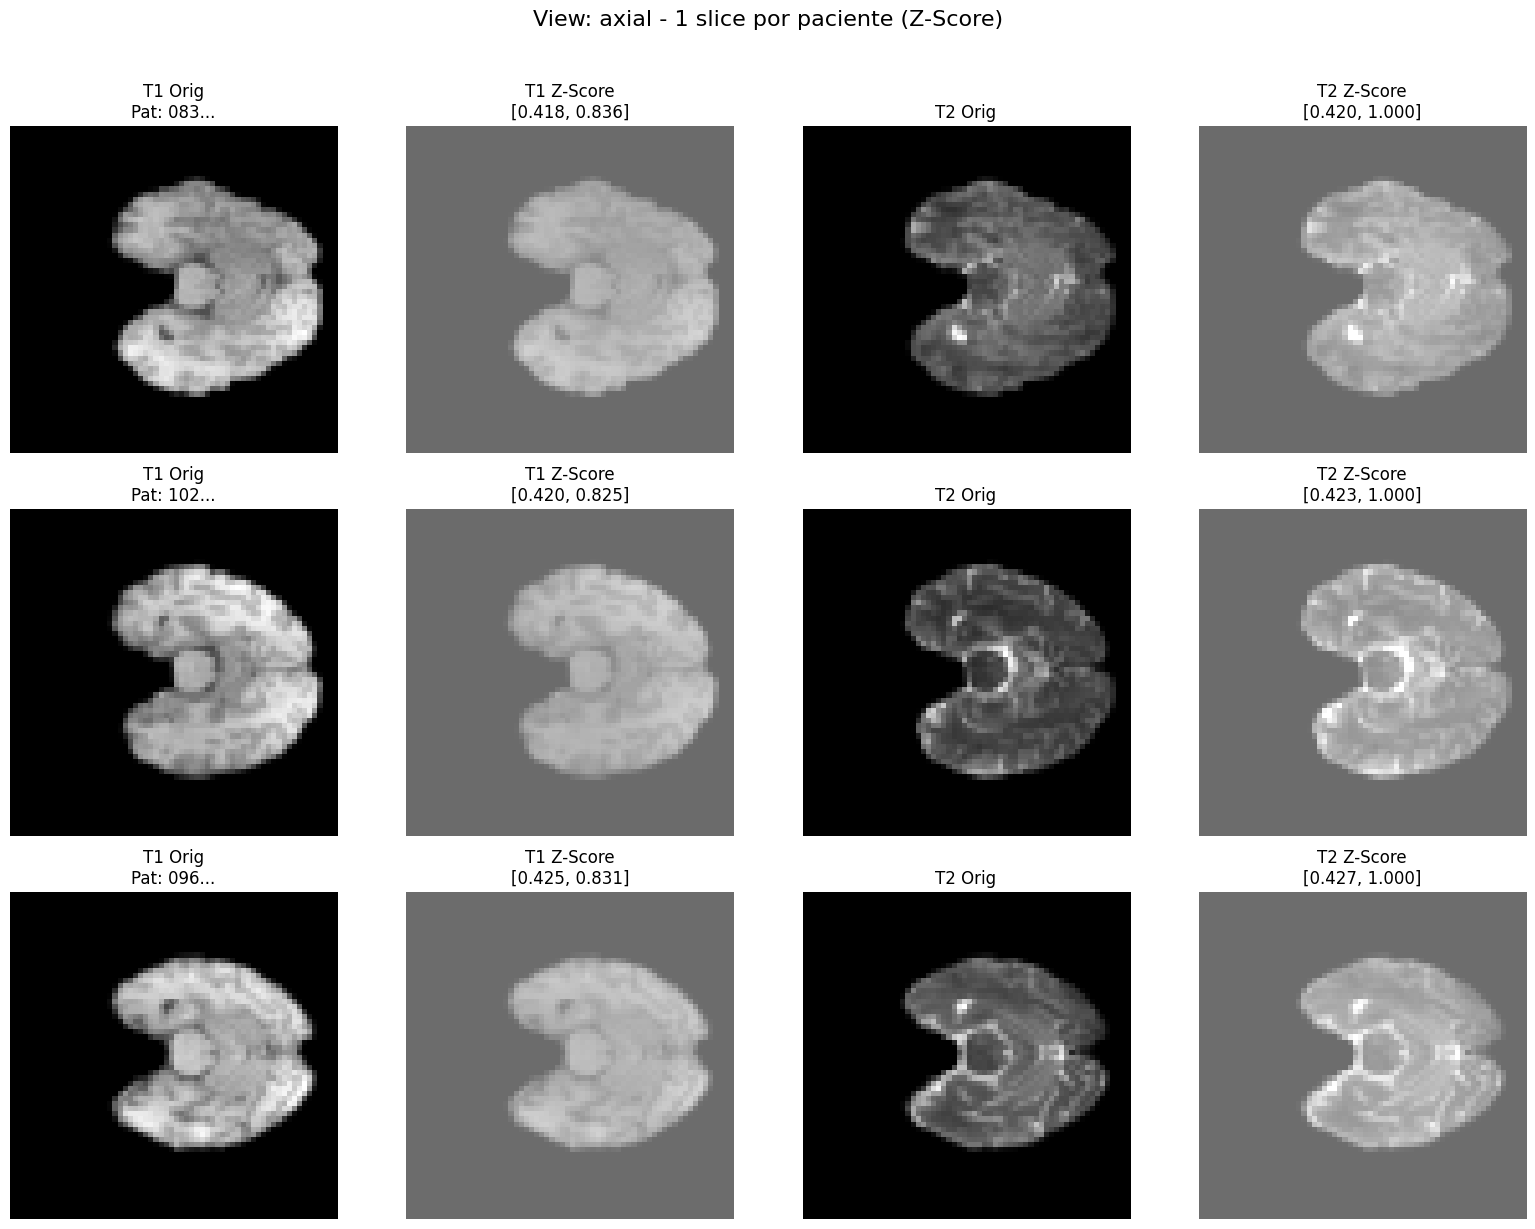

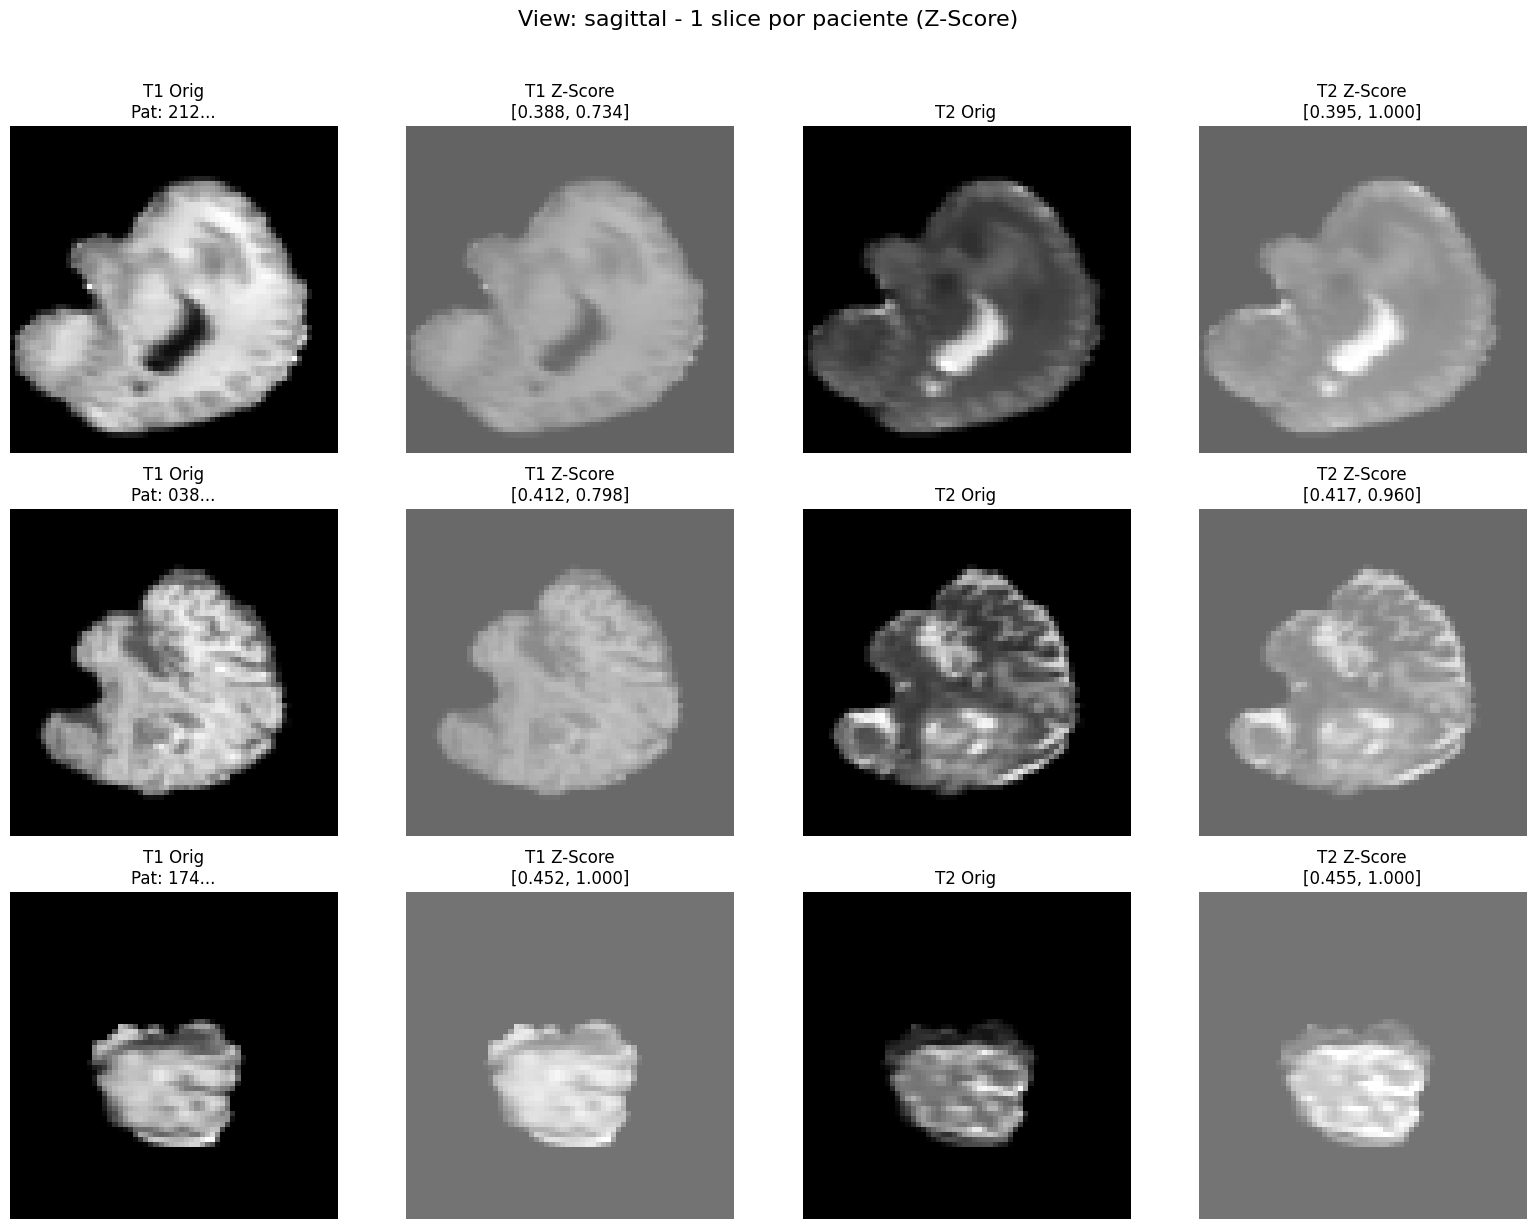

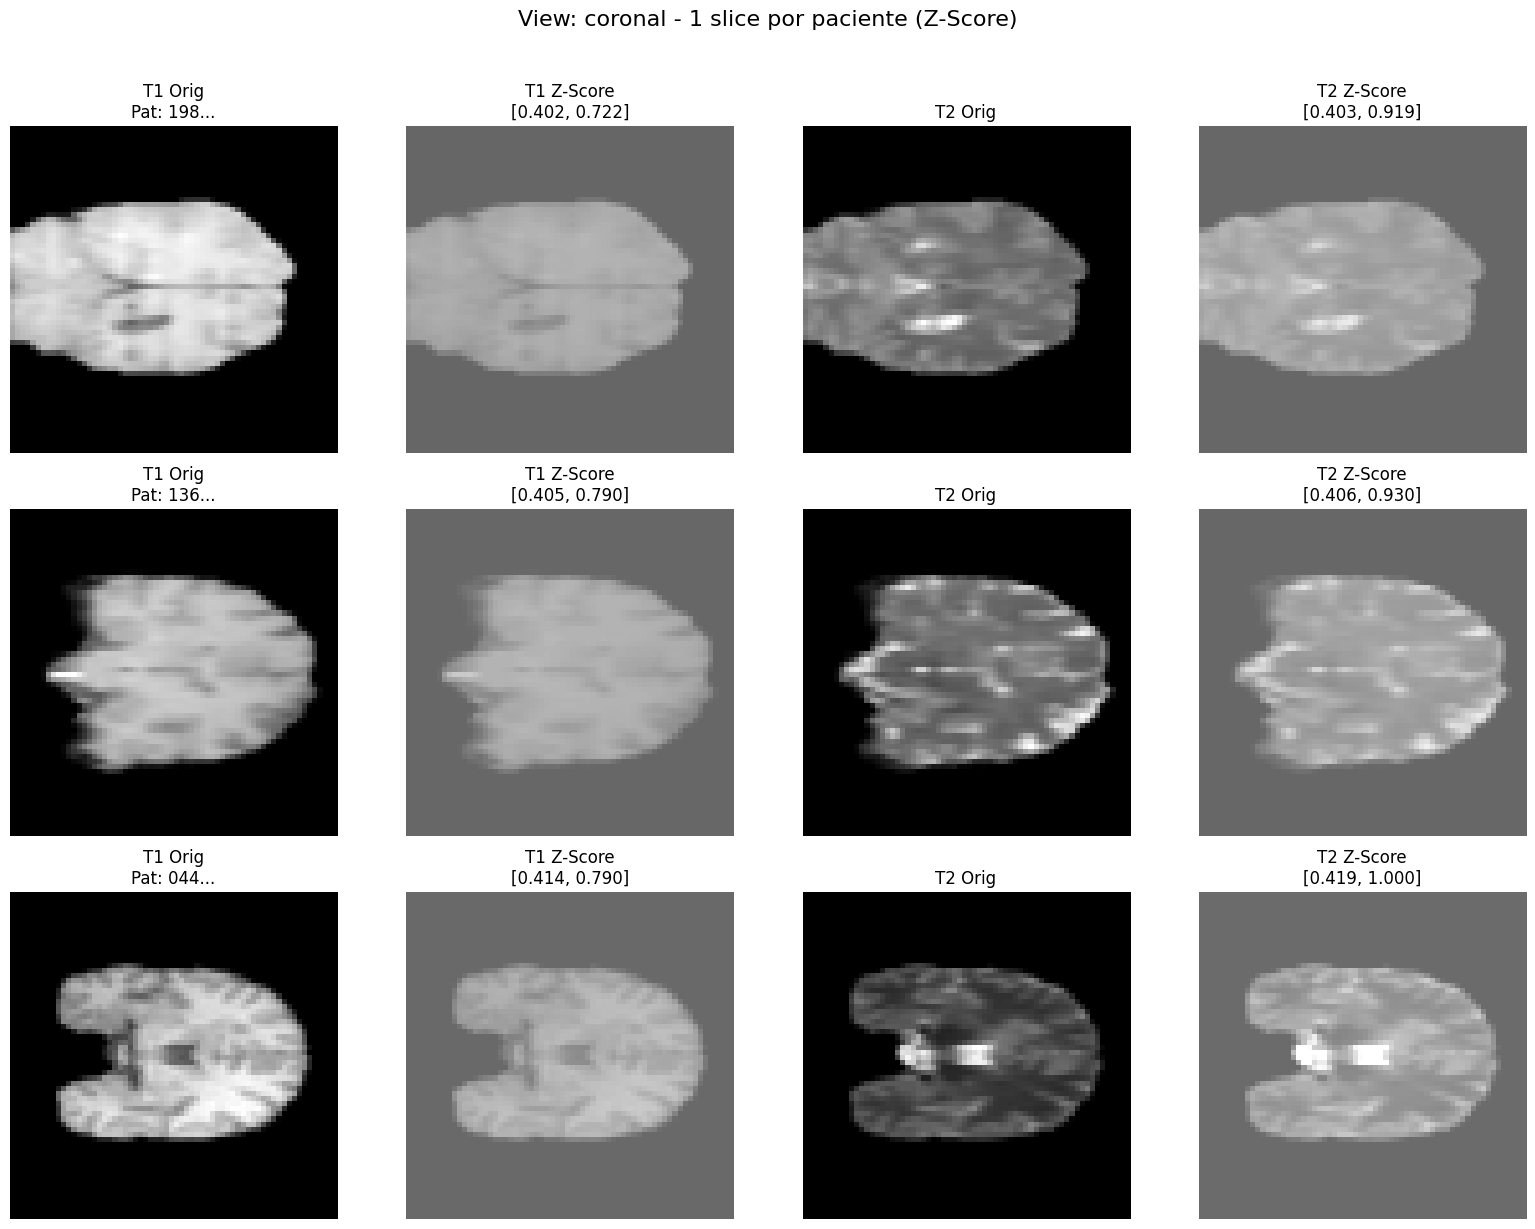

In [ ]:
# Define data dict for extract pacients per view for improving running time
print("Grouping pacientes per view...")

view_patient_to_indices = {'axial': {}, 'sagittal': {}, 'coronal': {}}

# Just running one time for the whole dataset
for idx, sample in enumerate(train_dataset):
    view = sample['view']
    patient = sample['patient_id']
    # Add patient slices
    if patient not in view_patient_to_indices[view]:
        view_patient_to_indices[view][patient] = []
    view_patient_to_indices[view][patient].append(idx)

print("Patients per view:")
for view, patients_dict in view_patient_to_indices.items():
    print(f"  {view}: {len(patients_dict)} pacientes")

# Taking slice per number of pacient per view
n_patients = 3

for view in view_patient_to_indices.keys():
    pacientes = list(view_patient_to_indices[view].keys())

    # Taking n_patients
    selected_patients = np.random.choice(pacientes, size=min(n_patients, len(pacientes)), replace=False)

    fig, axes = plt.subplots(n_patients, 4, figsize=(16, 4*n_patients))
    fig.suptitle(f'View: {view} - 1 slice por paciente (Z-Score)', fontsize=16, y=1.02)

    for i, patient in enumerate(selected_patients):
        # taking the slice from the random pacients
        patient_indices = view_patient_to_indices[view][patient]
        idx = np.random.choice(patient_indices)

        # assigning extracted samples for origina and norm data
        orig = train_dataset[int(idx)]
        norm = train_dataset_robust[int(idx)]

        axes[i, 0].imshow(orig['t1'].squeeze(), cmap='gray')
        axes[i, 0].set_title(f'T1 Orig\nPat: {patient[:8]}...')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(norm['t1'].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f'T1 Z-Score\n[{norm["t1"].min():.3f}, {norm["t1"].max():.3f}]')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(orig['t2'].squeeze(), cmap='gray')
        axes[i, 2].set_title(f'T2 Orig')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(norm['t2'].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[i, 3].set_title(f'T2 Z-Score\n[{norm["t2"].min():.3f}, {norm["t2"].max():.3f}]')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

<br><br>

## 1.B) Modality Translation (T1 → T2)

In this part you will build an **image-to-image model** that takes a T1-weighted slice as input and predicts the corresponding T2-weighted slice. Each training example is therefore a pair $(\text{T1}, \text{T2})$ with matching spatial dimensions.

You are free to design the model architecture, but it must satisfy the following requirements:

- It should operate on 2D slices and produce an output with the **same spatial resolution** as the input
- It should take `t1` as input and learn to approximate `t2` as output, using the pre-processed data from Part 1.A.  

In designing your solution, you must determine:

- a **suitable architecture**, keeping in mind that simpler models should remain functional and that more complex designs may yield improved performance;  
- the **loss function** and **optimisation setup** you believe appropriate for this task;  
- the **evaluation strategy**, including at least one quantitative metric and the qualitative visualisation of predicted T2 images.

Key points to consider:

- You are expected to design the full solution **yourself**: the model, the preprocessing pipeline, and the overall training procedure. You must also decide on **suitable evaluation metrics** for this problem. **Strong solutions will ensure that the model can both preserve image quality and generalise well to the validation set.**

- Only include code that is necessary to reproduce your results. Notebook organisation and clarity form part of the assessment (see the main *README*).

- You should ensure that the notebook clearly displays example outputs of your **final trained model on the validation set**, as well as at least one plot showing how your chosen **evaluation metric(s) evolve over training iterations or epochs.**

- You may include **up to two** solutions in this notebook, in recognition that partially working attempts may still receive marks under the criteria outlined in the *README*, but you are encouraged to start with a simple, reliable baseline before attempting a more complex model.


<br>

---

<br>

Write your answer to this question below. You can use as many code and text blocks as needed.

Please, **make sure to thoroughly describe and comment every piece of code that you include in your answer**. You will be expected to understand every line of code that you write.

<br>

In [7]:
class MRITranslationDataset(Dataset):
    """PyTorch Dataset for T1 to T2 prediction"""
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset
        # Input HuggingFace dataset already normalized
        self.length = len(hf_dataset)

    def __len__(self):
        return self.length  # Dataset lenght

    def __getitem__(self, idx):
         # Access to idx of the dataset
        return self.hf_dataset[idx]['t1'], self.hf_dataset[idx]['t2']

In [8]:
class AugmentedMRIDataset(Dataset):
    """Dataset con data augmentation simple"""
    def __init__(self, hf_dataset, augment=False):
        self.hf_dataset = hf_dataset
        self.augment = augment
        self.length = len(hf_dataset)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        t1 = sample['t1']
        t2 = sample['t2']

        if self.augment and random.random() > 0.5:
            # Flip horizontal simple
            t1 = torch.flip(t1, dims=[-1])
            t2 = torch.flip(t2, dims=[-1])

        return t1, t2

# Because our input dataset belongs to a dictionary we need to load datasets
# with a pytorch format
train_pt_dataset = AugmentedMRIDataset(train_dataset_robust, augment=True)
valid_pt_dataset = MRITranslationDataset(valid_dataset_robust)  # Sin augment en validación

In [9]:
# DataLoader creation for training and validation
train_loader = torch.utils.data.DataLoader(
    train_pt_dataset,
    batch_size=128, # Decided to increase from 32 to 128 taking advantage of GPU
    shuffle=True,
    num_workers=2, # Improve running times
    pin_memory=True # Improve running times in GPU
)

valid_loader = torch.utils.data.DataLoader(
    valid_pt_dataset,
    batch_size=128, # Decided to increase from 32 to 128 taking advantage of GPU
    shuffle=False, # No shuffle for validation
    num_workers=2, # Improve running times
    pin_memory=True # Improve running times in GPU
)

# Print batches per dataset
print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")

Train batches: 909
Valid batches: 308


In [10]:
class BasicConvNet(nn.Module):
    """
    Basic convolutional layer that keeps the resolution of the input layer

    """
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # First block with one input chanel(image) to 32 keeping 64 x 64
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # batch normalization same as the output from
            # the previous layer.
            nn.ReLU(inplace=True), # modified original tensor for memory
            # optimization
            nn.Dropout2d(0.2),

            # Second block from 32 to 64 keeping image seize
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [128, 64, 64, 64]
            nn.BatchNorm2d(64), # batch normalization same as the output from
            # the previous layer.
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),

            # Third block from 64 to 128 keeping image seize
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # [128, 128, 64, 64]
            nn.BatchNorm2d(128), # batch normalization same as the output from
            # the previous layer helping to stabilize input values
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            # Third block from 128 to 64 keeping image seize
            nn.Conv2d(128, 64, kernel_size=3, padding=1),  # [128, 64, 64, 64]
            nn.BatchNorm2d(64), # batch normalization same as the output from
            # the previous layer.
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            # Fourth block from 64 to 32
            # keeping image seize
            nn.Conv2d(64, 32, kernel_size=3, padding=1),  # [128, 32, 64, 64]
            nn.BatchNorm2d(32), # batch normalization same as the output from
            # the previous layer.
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05),

            # Fifth block from 32 to 1
            # keeping image seize
            nn.Conv2d(32, 1, kernel_size=3, padding=1),   # [128, 1, 64, 64]
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.network(x)

In [11]:
# Select the computing device: GPU (cuda) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Create an instance of the model and move it to the selected device
model = BasicConvNet().to(device)

# Count total number of parameters in the model (trainable + non-trainable)
total_params = sum(p.numel() for p in model.parameters())
# Count only trainable parameters (those with requires_grad=True)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n=== Model information ===")
print(f"Total parameters: {total_params:,}")
print(f"Training parameters: {trainable_params:,}")

# Architecture summary
print(f"\n=== Architecture Sumary ===")
for i, layer in enumerate(model.network):
    layer_type = layer.__class__.__name__
    if hasattr(layer, 'in_channels') and hasattr(layer, 'out_channels'):
        print(f"Layer {i:2d}: {layer_type:15s} {layer.in_channels}→{layer.out_channels} channels")
    else:
        print(f"Layer {i:2d}: {layer_type:15s}")

Device: cuda

=== Model information ===
Total parameters: 185,857
Training parameters: 185,857

=== Architecture Sumary ===
Layer  0: Conv2d          1→32 channels
Layer  1: BatchNorm2d    
Layer  2: ReLU           
Layer  3: Dropout2d      
Layer  4: Conv2d          32→64 channels
Layer  5: BatchNorm2d    
Layer  6: ReLU           
Layer  7: Dropout2d      
Layer  8: Conv2d          64→128 channels
Layer  9: BatchNorm2d    
Layer 10: ReLU           
Layer 11: Dropout2d      
Layer 12: Conv2d          128→64 channels
Layer 13: BatchNorm2d    
Layer 14: ReLU           
Layer 15: Dropout2d      
Layer 16: Conv2d          64→32 channels
Layer 17: BatchNorm2d    
Layer 18: ReLU           
Layer 19: Dropout2d      
Layer 20: Conv2d          32→1 channels
Layer 21: ReLU           


In [12]:
# convert the batch in an iterator and iterate to get one batch from the dataloader
t1_batch, t2_batch = next(iter(train_loader))

# Move the batch to the device
t1_batch = t1_batch.to(device)
t2_batch = t2_batch.to(device)

# Set the model evaluation
model.eval()
# Disable the gradient computation for training and save memory
with torch.no_grad():
    # Forward pass, predictions
    t2_pred = model(t1_batch)

    print(f"\n=== Test with real data ===")
    print(f"Batch size: {t1_batch.shape[0]}")
    print(f"Input shape:  {t1_batch.shape}")
    print(f"Output shape: {t2_pred.shape}")

    # Verify values and normalization ranges, for young networks T2 could have
    # negative values because no activation function is applied on last layer.
    # Good QC for training layer
    print(f"\nRange values:")
    print(f"  T1 input:  [{t1_batch.min():.4f}, {t1_batch.max():.4f}]")
    print(f"  T2 target: [{t2_batch.min():.4f}, {t2_batch.max():.4f}]")
    print(f"  T2 pred:   [{t2_pred.min():.4f}, {t2_pred.max():.4f}]")

    # No NAN values QC
    if torch.isnan(t2_pred).any():
        print("NAN values!")
    else:
        print("no NAN values")


=== Test with real data ===
Batch size: 128
Input shape:  torch.Size([128, 1, 64, 64])
Output shape: torch.Size([128, 1, 64, 64])

Range values:
  T1 input:  [0.3733, 1.0000]
  T2 target: [0.3752, 1.0000]
  T2 pred:   [0.0318, 0.0423]
no NAN values


In [13]:
# Loss function
criterion = nn.L1Loss()  # Mean Absolute Error (MAE). Measures average absolute
# difference between prediction and target.

# Optimizer with fixed learning rate
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5  # L2 regularization. Helps prevent overfitting by
# penalizing large weights.

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY  # Add weight decay (L2 penalty)
)

# Print basic configuration
print(f"\n=== SIMPLIFIED CONFIGURATION ===")
print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: Adam")
print(f"Fixed learning rate: {LEARNING_RATE}")
print(f"Batch size: {128}")



=== SIMPLIFIED CONFIGURATION ===
Loss function: L1Loss
Optimizer: Adam
Fixed learning rate: 0.001
Batch size: 128


In [14]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one complete epoch.

    """
    # Set model to training mode
    model.train()

    # Initialize epoch statistics
    total_loss = 0.0
    total_samples = 0

    # Create progress bar for batch monitoring
    batch_pbar = tqdm(train_loader, desc="Training", leave=False)

    # Iterate through all training batches
    for batch_idx, (t1_batch, t2_batch) in enumerate(batch_pbar):

        # Transfer data to target device (non-blocking for efficiency)
        t1_batch = t1_batch.to(device, non_blocking=True)
        t2_batch = t2_batch.to(device, non_blocking=True)

        # Reset gradients from previous batch
        optimizer.zero_grad()

        # Forward pass: generate predictions
        t2_pred = model(t1_batch)

        # Compute loss between predictions and ground truth
        batch_loss = criterion(t2_pred, t2_batch)

        # Backward pass: compute gradients
        batch_loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate statistics (weighted by batch size)
        batch_size = t1_batch.size(0)
        total_loss += batch_loss.item() * batch_size
        total_samples += batch_size

        # Update progress bar with current batch loss
        batch_pbar.set_postfix({'loss': f'{batch_loss.item():.4f}'})

    # Calculate average loss for the epoch
    average_loss = total_loss / total_samples if total_samples > 0 else 0.0

    return average_loss

In [15]:
def validate_epoch(model, val_loader, criterion, device):
    """
    Validate the model on the validation dataset.

    """
    # Set model to evaluation mode (disables dropout, uses batch norm statistics)
    model.eval()

    # Initialize validation statistics
    total_loss = 0.0
    total_samples = 0

    # Disable gradient computation for efficiency
    with torch.no_grad():
        # Iterate through validation batches
        for t1_batch, t2_batch in val_loader:

            # Transfer data to target device
            t1_batch = t1_batch.to(device, non_blocking=True)
            t2_batch = t2_batch.to(device, non_blocking=True)

            # Forward pass (no gradient tracking)
            t2_pred = model(t1_batch)

            # Compute loss
            batch_loss = criterion(t2_pred, t2_batch)

            # Accumulate statistics
            batch_size = t1_batch.size(0)
            total_loss += batch_loss.item() * batch_size
            total_samples += batch_size

    # Calculate average validation loss
    average_loss = total_loss / total_samples if total_samples > 0 else 0.0

    return average_loss

In [16]:
# Training configuration
NUM_EPOCHS = 30
train_losses = []
valid_losses = []

print(f"🚀 SEPARATED TRAINING PIPELINE")
print(f"Device: {device}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(valid_loader.dataset)}")

# Inizialitation for tie calculation
global_start_time = time.time()
epoch_times = []

# Training loop
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*50}")

    # ============ TRAINING PHASE ============
    print("Phase 1: Training")
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    # ============ VALIDATION PHASE ============
    print("Phase 2: Validation")
    valid_loss = validate_epoch(model, valid_loader, criterion, device)
    valid_losses.append(valid_loss)

    # Calculate epoch duration
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    # Display results
    print(f"\nEpoch Summary:")
    print(f"  Training Loss:   {train_loss:.6f}")
    print(f"  Validation Loss: {valid_loss:.6f}")
    print(f"  Loss Difference: {train_loss - valid_loss:.6f}")
    print(f"  Epoch Duration:  {epoch_time:.2f} seconds")

    # Early stopping check (optional)
    if len(valid_losses) >= 2:
        if valid_losses[-1] > valid_losses[-2]:
            print(f"⚠️  Validation loss increased from {valid_losses[-2]:.6f} to {valid_losses[-1]:.6f}")

    # Time estimation
    if epoch < NUM_EPOCHS - 1:
        avg_epoch_time = sum(epoch_times) / len(epoch_times)
        remaining_epochs = NUM_EPOCHS - (epoch + 1)
        estimated_remaining = (avg_epoch_time * remaining_epochs) / 60
        print(f"  Estimated remaining: {estimated_remaining:.1f} minutes")

# ============ TRAINING COMPLETION ============
print(f"\n{'='*50}")
print("TRAINING COMPLETED")
print(f"{'='*50}")
print(f"Total epochs trained: {len(train_losses)}")
print(f"Best training loss: {min(train_losses):.6f}")
print(f"Best validation loss: {min(valid_losses):.6f}")
best_epoch = valid_losses.index(min(valid_losses)) + 1
print(f"Best model epoch: {best_epoch}")
print(f"Total training time: {(time.time() - global_start_time)/60:.1f} minutes")
print(f"{'='*50}")

# ============ SAVE FINAL MODEL ============
# Save model weights only (for inference)
model_weights_path = 'final_model_weights.pth'
torch.save(model.state_dict(), model_weights_path)
print(f"✓ Model weights saved: {model_weights_path}")

# Save complete checkpoint (for resuming training)
checkpoint_path = 'final_model_checkpoint.pth'
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'valid_losses': valid_losses,
    'best_epoch': best_epoch,
    'best_train_loss': min(train_losses),
    'best_valid_loss': min(valid_losses),
    'batch_size': train_loader.batch_size,
    'device': str(device)
}
torch.save(checkpoint, checkpoint_path)
print(f"✓ Complete checkpoint saved: {checkpoint_path}")

🚀 SEPARATED TRAINING PIPELINE
Device: cuda
Batch size: 128
Total epochs: 30
Training samples: 116235
Validation samples: 39375

Epoch 1/30
Phase 1: Training


Phase 2: Validation



Epoch Summary:
  Training Loss:   0.042788
  Validation Loss: 0.028009
  Loss Difference: 0.014779
  Epoch Duration:  260.34 seconds
  Estimated remaining: 125.8 minutes

Epoch 2/30
Phase 1: Training


Phase 2: Validation



Epoch Summary:
  Training Loss:   0.030638
  Validation Loss: 0.025127
  Loss Difference: 0.005511
  Epoch Duration:  260.73 seconds
  Estimated remaining: 121.6 minutes

Epoch 3/30
Phase 1: Training


...


Epoch Summary:
  Training Loss:   0.019406
  Validation Loss: 0.022143
  Loss Difference: -0.002737
  Epoch Duration:  258.25 seconds
⚠️  Validation loss increased from 0.021187 to 0.022143
  Estimated remaining: 8.5 minutes

Epoch 29/30
Phase 1: Training


Phase 2: Validation



Epoch Summary:
  Training Loss:   0.019317
  Validation Loss: 0.021487
  Loss Difference: -0.002170
  Epoch Duration:  255.87 seconds
  Estimated remaining: 4.3 minutes

Epoch 30/30
Phase 1: Training


Phase 2: Validation



Epoch Summary:
  Training Loss:   0.019254
  Validation Loss: 0.021011
  Loss Difference: -0.001756
  Epoch Duration:  255.93 seconds

TRAINING COMPLETED
Total epochs trained: 30
Best training loss: 0.019254
Best validation loss: 0.021011
Best model epoch: 30
Total training time: 128.2 minutes
✓ Model weights saved: final_model_weights.pth
✓ Complete checkpoint saved: final_model_checkpoint.pth


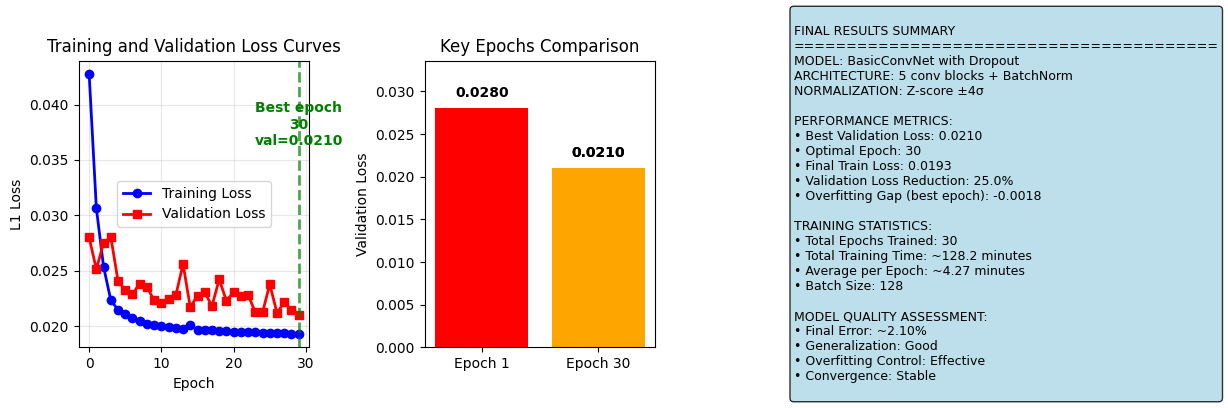

✓ Training results plot saved as 'third_training_results.png'
✓ Overfitting analysis plot saved as 'overfitting_analysis.png'


<Figure size 640x480 with 0 Axes>

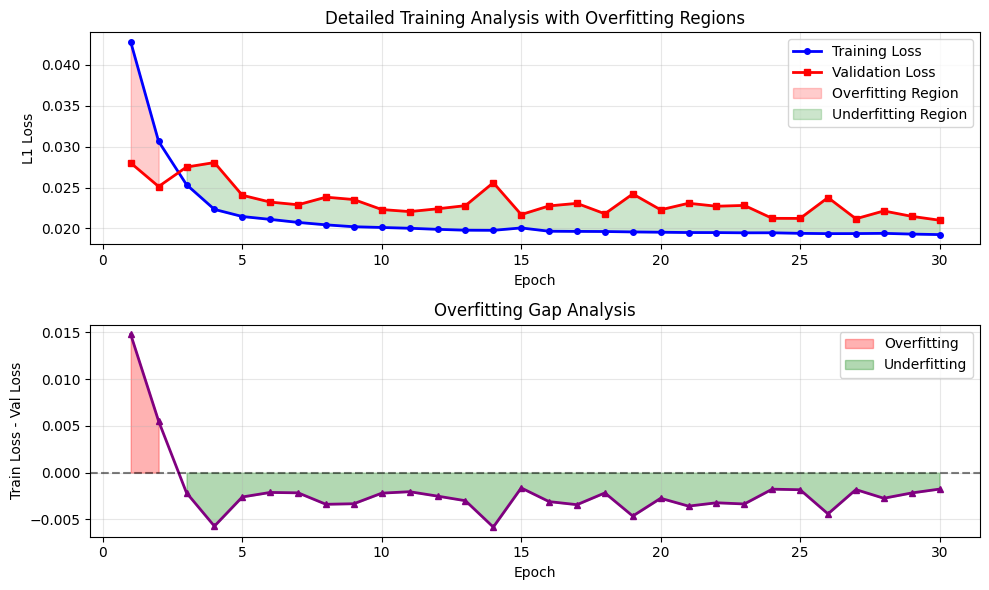

In [17]:
## Chat GPT plot analysis recomendation

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# 1. TRAINING CURVES
plt.subplot(1, 3, 1)
plt.plot(train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(valid_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark the best epoch
best_epoch = valid_losses.index(min(valid_losses))
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2)
plt.text(best_epoch, max(max(train_losses), max(valid_losses)) * 0.85,
         f'Best epoch\n{best_epoch+1}\nval={min(valid_losses):.4f}',
         ha='center', color='green', fontweight='bold')

# 2. PERFORMANCE COMPARISON BAR CHART
plt.subplot(1, 3, 2)
epochs_to_compare = [1, best_epoch+1, len(valid_losses)]  # First, best, and last epoch
loss_values = [valid_losses[0], min(valid_losses), valid_losses[-1]]
colors = ['red', 'green', 'orange']
epoch_labels = [f'Epoch {e}' for e in epochs_to_compare]

bars = plt.bar(epoch_labels, loss_values, color=colors)
plt.ylabel('Validation Loss')
plt.title('Key Epochs Comparison')
plt.ylim(0, max(loss_values) * 1.2)

# Add values on top of bars
for bar, val in zip(bars, loss_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# 3. NUMERICAL SUMMARY
plt.subplot(1, 3, 3)
plt.axis('off')

# Calculate training time statistics
total_training_time = sum(epoch_times) if 'epoch_times' in locals() else len(train_losses) * 260  # Approximate if not tracked
avg_epoch_time = total_training_time / len(train_losses) if len(train_losses) > 0 else 0

# Calculate improvement metrics
initial_val_loss = valid_losses[0] if valid_losses else 0
best_val_loss = min(valid_losses) if valid_losses else 0
reduction_percentage = 100 * (initial_val_loss - best_val_loss) / initial_val_loss if initial_val_loss > 0 else 0

# Calculate overfitting gap at best epoch
overfitting_gap = train_losses[best_epoch] - valid_losses[best_epoch] if best_epoch < len(train_losses) else 0

summary_text = f"""
FINAL RESULTS SUMMARY
{'='*40}
MODEL: BasicConvNet with Dropout
ARCHITECTURE: 5 conv blocks + BatchNorm
NORMALIZATION: Z-score ±4σ

PERFORMANCE METRICS:
• Best Validation Loss: {min(valid_losses):.4f}
• Optimal Epoch: {best_epoch + 1}
• Final Train Loss: {train_losses[-1]:.4f}
• Validation Loss Reduction: {reduction_percentage:.1f}%
• Overfitting Gap (best epoch): {overfitting_gap:.4f}

TRAINING STATISTICS:
• Total Epochs Trained: {len(train_losses)}
• Total Training Time: ~{total_training_time/60:.1f} minutes
• Average per Epoch: ~{avg_epoch_time/60:.2f} minutes
• Batch Size: {train_loader.batch_size}

MODEL QUALITY ASSESSMENT:
• Final Error: ~{(valid_losses[-1]*100):.2f}%
• Generalization: {'Good' if overfitting_gap < 0.002 else 'Needs Improvement'}
• Overfitting Control: {'Effective' if abs(overfitting_gap) < 0.002 else 'Review Needed'}
• Convergence: {'Stable' if valid_losses[-1] < valid_losses[-2] else 'Fluctuating'}
"""

plt.text(0.1, 0.5, summary_text, fontsize=9,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

# Save the plot as image file
plt.savefig('third_training_results.png', dpi=150, bbox_inches='tight')
print(f"✓ Training results plot saved as 'third_training_results.png'")

# Optional: Additional detailed plot for overfitting analysis
plt.figure(figsize=(10, 6))

# Plot 1: Main loss curves
plt.subplot(2, 1, 1)
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, valid_losses, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
plt.fill_between(epochs, train_losses, valid_losses, where=[t > v for t, v in zip(train_losses, valid_losses)],
                 color='red', alpha=0.2, label='Overfitting Region')
plt.fill_between(epochs, train_losses, valid_losses, where=[t < v for t, v in zip(train_losses, valid_losses)],
                 color='green', alpha=0.2, label='Underfitting Region')
plt.xlabel('Epoch')
plt.ylabel('L1 Loss')
plt.title('Detailed Training Analysis with Overfitting Regions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Overfitting gap over time
plt.subplot(2, 1, 2)
overfitting_gaps = [train - valid for train, valid in zip(train_losses, valid_losses)]
plt.plot(epochs, overfitting_gaps, 'purple', linewidth=2, marker='^', markersize=4)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.fill_between(epochs, overfitting_gaps, 0, where=[g > 0 for g in overfitting_gaps],
                 color='red', alpha=0.3, label='Overfitting')
plt.fill_between(epochs, overfitting_gaps, 0, where=[g < 0 for g in overfitting_gaps],
                 color='green', alpha=0.3, label='Underfitting')
plt.xlabel('Epoch')
plt.ylabel('Train Loss - Val Loss')
plt.title('Overfitting Gap Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150, bbox_inches='tight')
print(f"✓ Overfitting analysis plot saved as 'overfitting_analysis.png'")
plt.show()


=== VISUALIZACIÓN DE PREDICCIONES ===


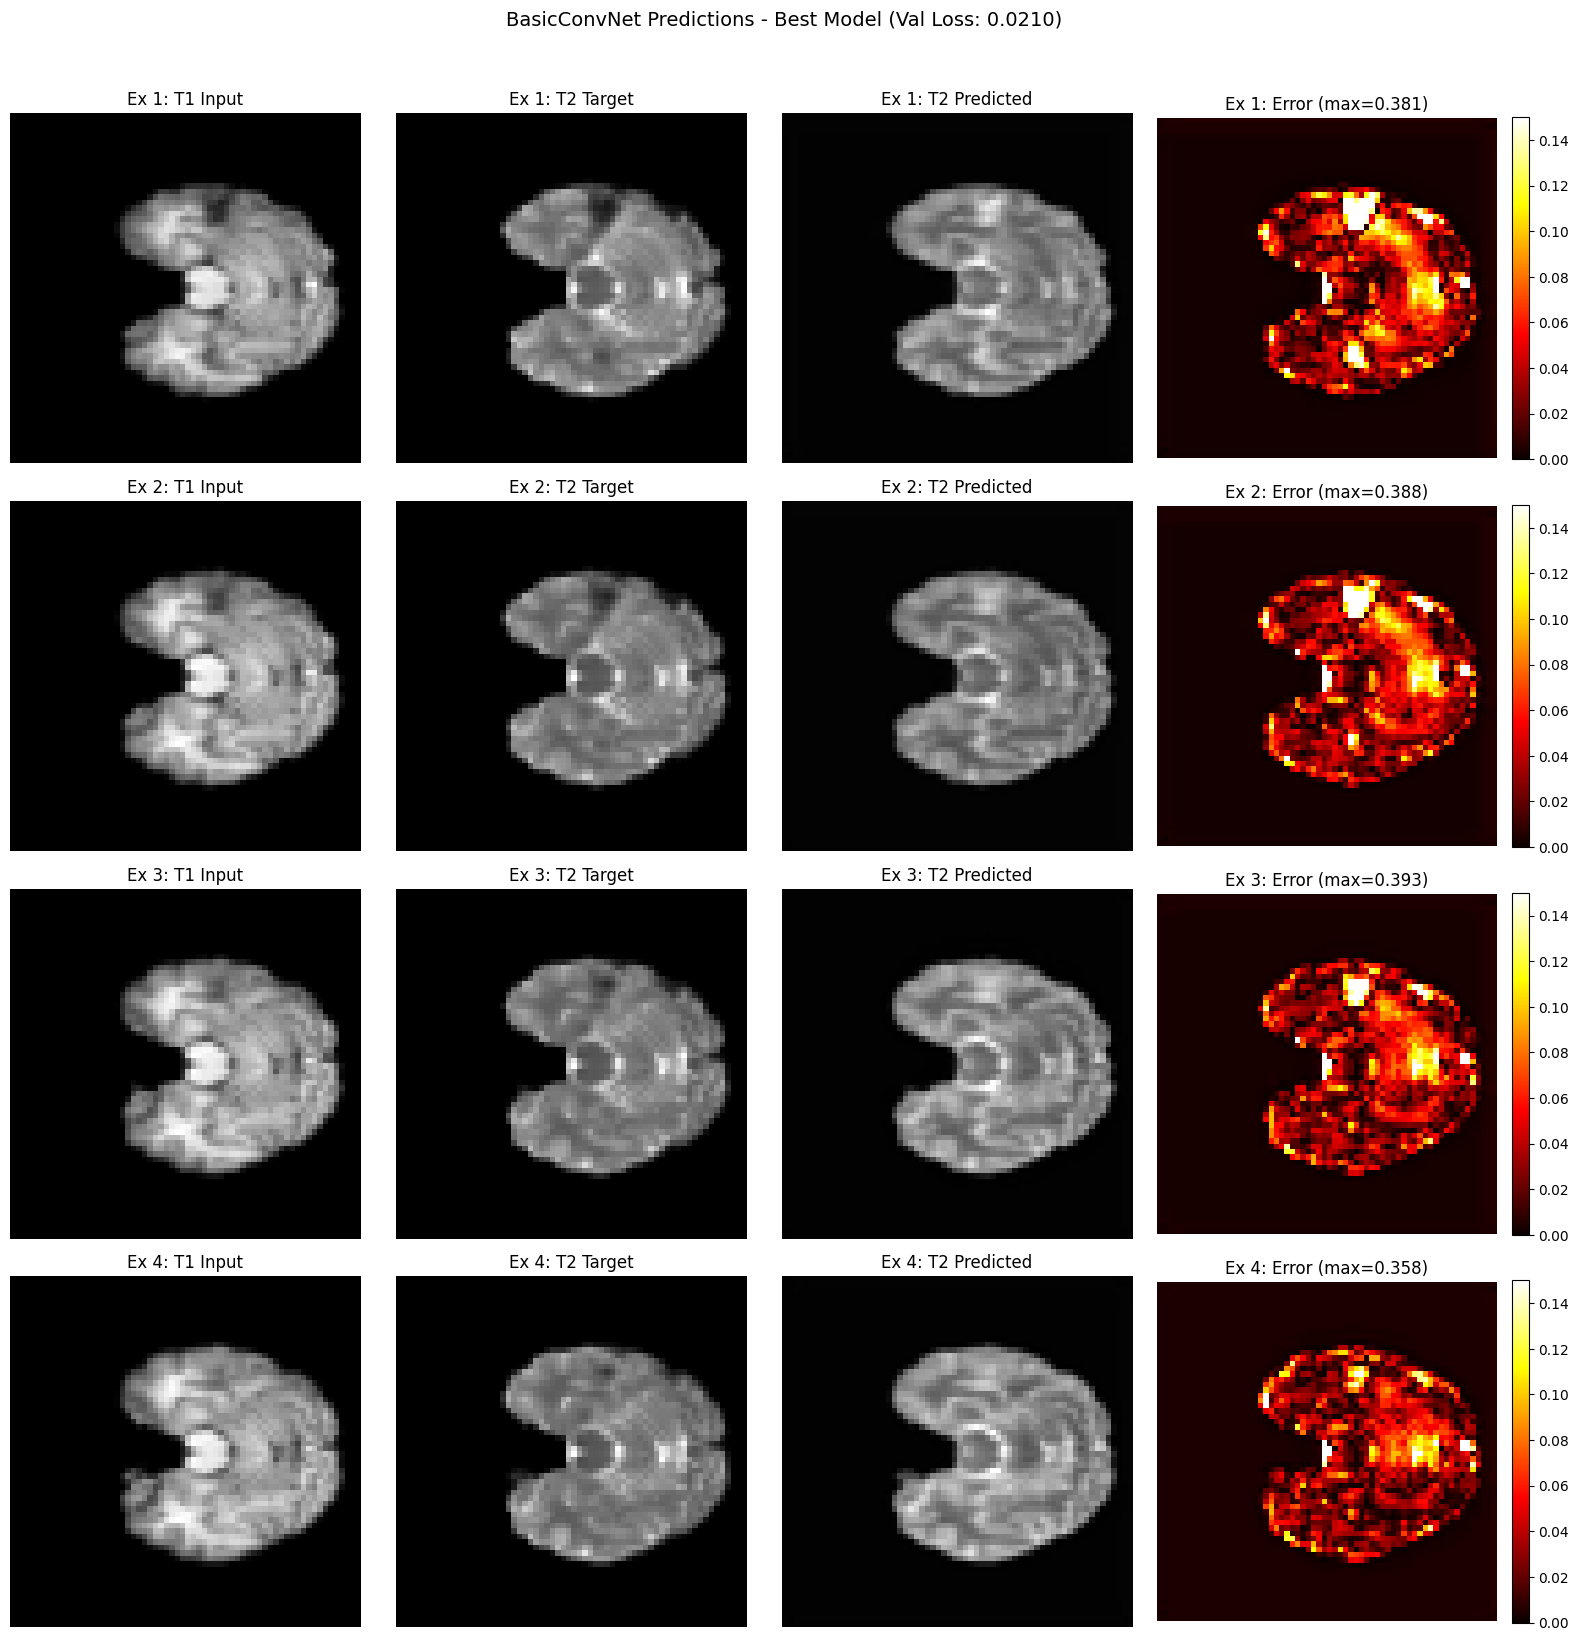

In [18]:
# Loading model for visualization QC between T1 T2 original and T2 prediced data
model.load_state_dict(torch.load('final_model_weights.pth'))
model.eval()

# visualization function
def visualize_comparison(model, dataloader, device, n_examples=4):
    model.eval()

    fig, axes = plt.subplots(n_examples, 4, figsize=(16, 4*n_examples))

    with torch.no_grad():
        t1_batch, t2_batch = next(iter(dataloader))
        t1_batch = t1_batch.to(device)
        t2_pred = model(t1_batch)

        t1_batch = t1_batch.cpu().numpy()
        t2_batch = t2_batch.numpy()
        t2_pred = t2_pred.cpu().numpy()

        for i in range(n_examples):
            # T1 Input
            axes[i, 0].imshow(t1_batch[i, 0], cmap='gray')
            axes[i, 0].set_title(f'Ex {i+1}: T1 Input')
            axes[i, 0].axis('off')

            # T2 Ground Truth
            axes[i, 1].imshow(t2_batch[i, 0], cmap='gray')
            axes[i, 1].set_title(f'Ex {i+1}: T2 Target')
            axes[i, 1].axis('off')

            # T2 Predicted
            axes[i, 2].imshow(t2_pred[i, 0], cmap='gray')
            axes[i, 2].set_title(f'Ex {i+1}: T2 Predicted')
            axes[i, 2].axis('off')

            # Plotting Absolute error for the predicted data
            # closer to white larger the error while red is smaller
            error = np.abs(t2_batch[i, 0] - t2_pred[i, 0])
            im = axes[i, 3].imshow(error, cmap='hot', vmin=0, vmax=0.15)
            axes[i, 3].set_title(f'Ex {i+1}: Error (max={error.max():.3f})')
            axes[i, 3].axis('off')
            plt.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

    plt.suptitle(f'BasicConvNet Predictions - Best Model (Val Loss: {min(valid_losses):.4f})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print("\n=== VISUALIZACIÓN DE PREDICCIONES ===")
visualize_comparison(model, valid_loader, device, n_examples=4)

<br><br>

## 1.C) Discussion (max 250 words)

In this part you should provide a concise written discussion (maximum **250 words**) reflecting on your solution to Part 1.B. Your discussion should address the following points:

1. **Modelling choices and pre-processing**  
   Explain the main decisions behind your model architecture, loss function, and training strategy, and how they relate to the properties of the T1/T2 translation task.

2. **Performance and evaluation**  
   Interpret your **quantitative** results and **qualitative** reconstructions. Comment on how well your model appears to reconstruct `t2` features.

3. **Limitations and possible improvements**  
   Identify the main limitations of your current approach and outline concrete avenues for improvement. You may refer to alternative architectures, loss functions, or improved training and validation procedures.

Your answer should be technically focused, directly address these points, and remain within the stated word limit. Overly long or off-topic discussions will be penalised.


<br>

---

<br>

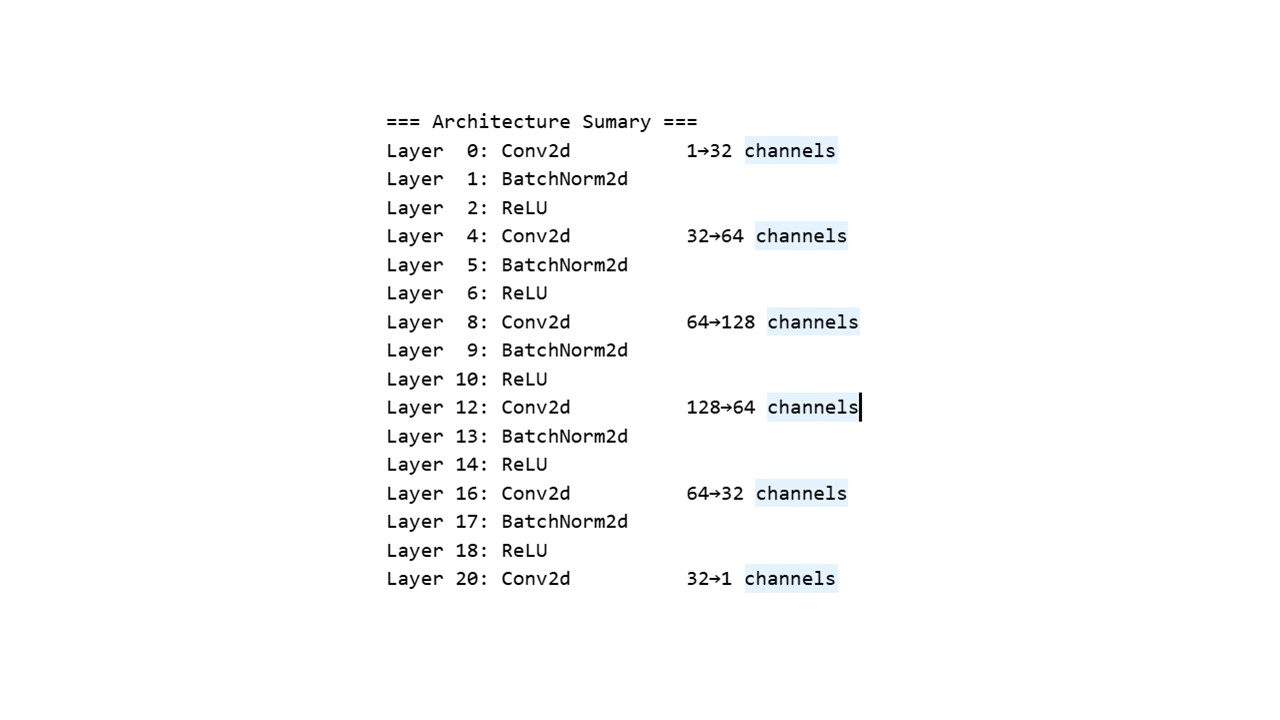
Based on comparative analysis of the four training runs, we identified significant progress in overfitting control and model stability.

Initially, the **first training** run without dropout, a deep 6 Neural Blocks (3x3) but simple simetrical architecture that keep the image size. This architecture use RELU activation function at the end of every block (except in the last one as a QC for the inizialization training according the output parameters of the first epoch) to properly handle non linearities. And Batch normalization in each block for keeping stability. This training exhibited severe overfitting with a gap of 0.0077 between training and validation losses.



Introducing progressive dropout in the second training run reduced this gap by 85%, demonstrating the effectiveness of regularization. However, although it temporarily achieved an excellent validation loss of 0.0185 in epoch 7, it suffered a catastrophic final spike that raised the loss to 0.0246, indicating late data memorization.
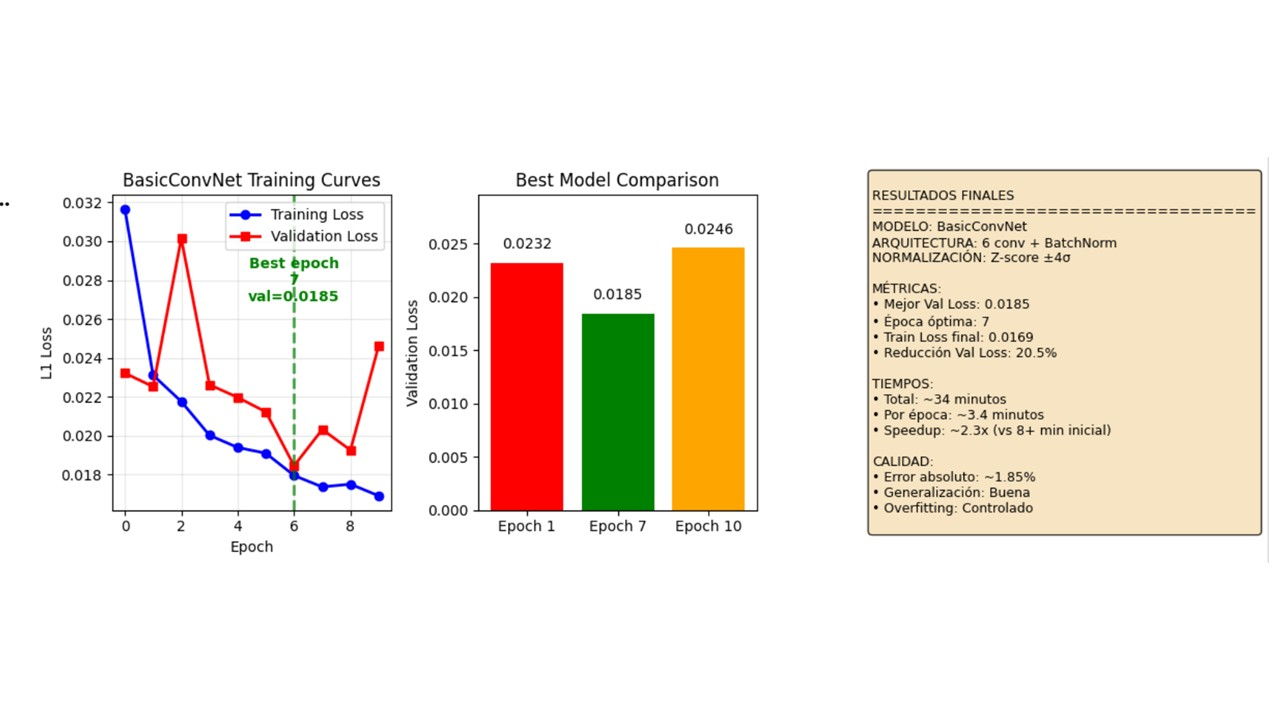


The third and fourth training sessions incorporated additional improvements such as data augmentation (horizontal flips), weight decay in the optimizer, and a separate pipeline architecture that improved stability. In particular, the fourth training session added ReLU activation in the final block of the network, resulting in the best overall balance: a final validation loss of 0.0210 with a controlled gap of 0.0018. Although it exhibits occasional spikes during training, these are less concerning than the silent overfitting of the second session, as the model shows resilience and ends with robust generalization.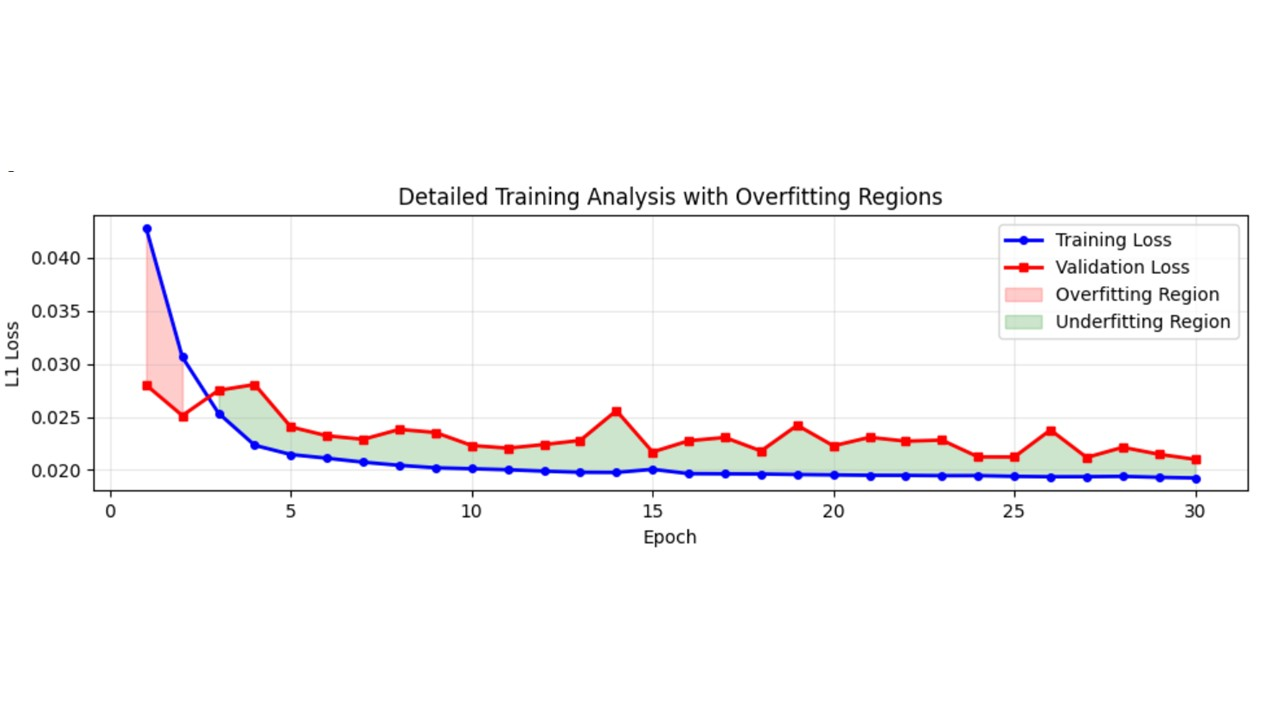

In the last training we have some spikes in epocj 14, 19 and 27, despite we are continuosly converging, this spikes can be fixed with a diferent architecture that stabilize and better predict the parameters for imaging predictions such as a U NET with skip conection.

** Visualization QC between first and last training training

This grid shows, T1 for one paciente of one view, the Target T2 and the predicted T2. At the right side of the image we can see a heat map op the brain where whiter colors indicate higher absolute error between the target and the predicted T2 while red indicate a good precition

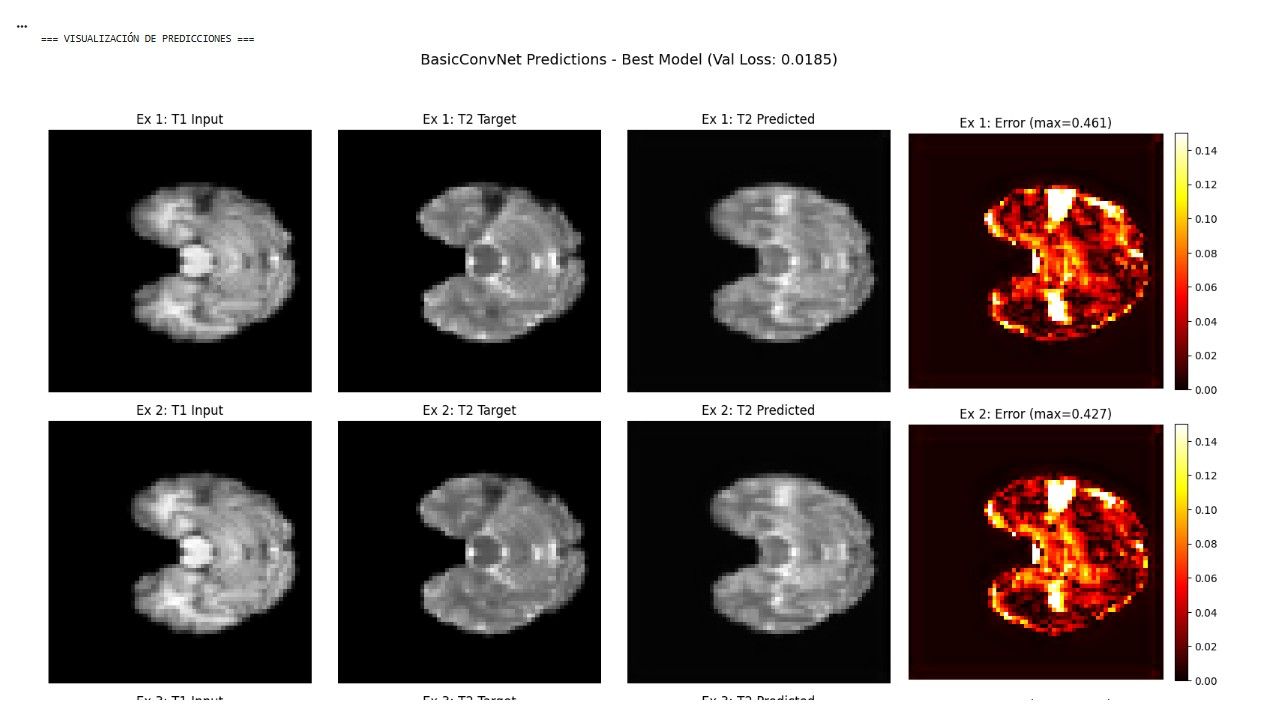

Last Training

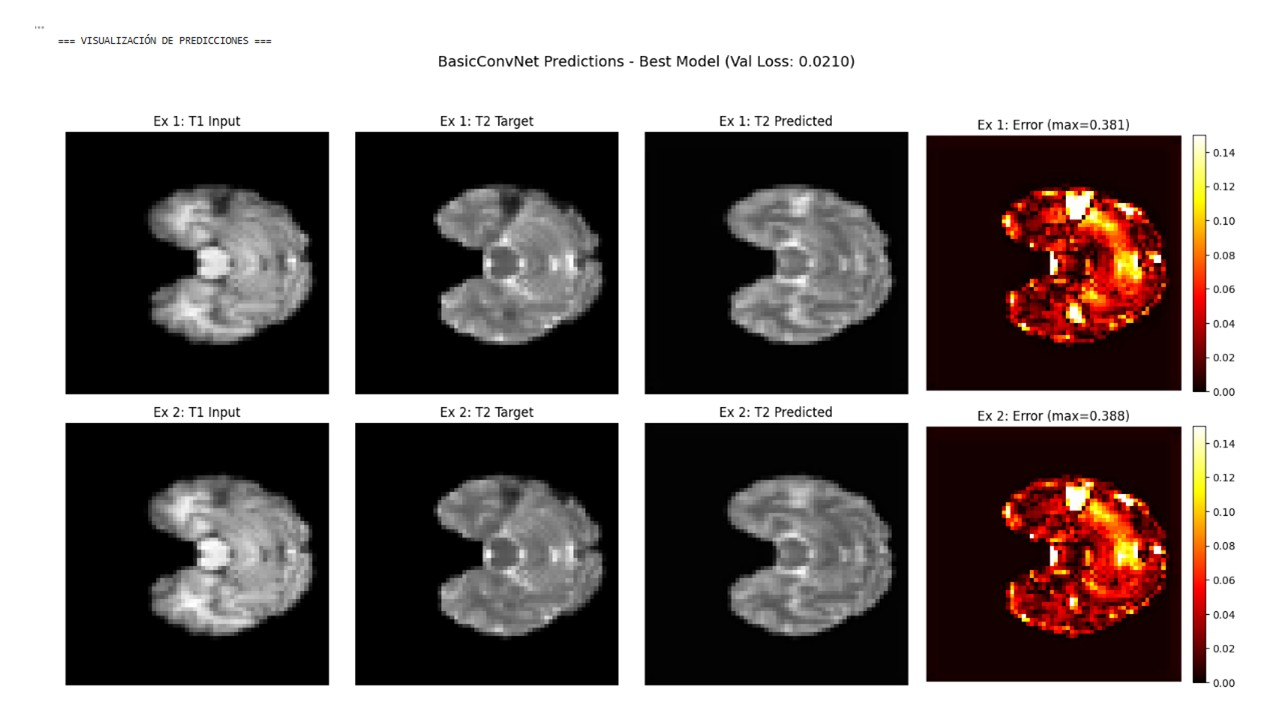

<br>

---

<br>